# Orbital Motion under Inverse-Square Law

## Objective
To simulate the motion of a body under gravitational force using Euler's method and study:
- Different types of orbits
- Effect of step size
- Energy variation over time

---

## Gravitational Potential and Force

The given potential is:
$$
V(r) = -\frac{4\pi^2}{r}
$$

The force is:
$$
\vec{F} = -\nabla V = -\frac{4\pi^2}{r^3} \vec{r}
$$

---

## Equations of Motion

Let position be:
$$
\vec{r} = (x, y)
$$

Then:
$$
\frac{dx}{dt} = v_x, \quad \frac{dy}{dt} = v_y
$$

$$
\frac{dv_x}{dt} = -\frac{4\pi^2 x}{r^3}, \quad
\frac{dv_y}{dt} = -\frac{4\pi^2 y}{r^3}
$$

where:
$$
r = \sqrt{x^2 + y^2}
$$

---

## Euler Method

We approximate derivatives using finite differences:

$$
x_{n+1} = x_n + v_x \Delta t
$$

$$
y_{n+1} = y_n + v_y \Delta t
$$

$$
v_{x,n+1} = v_{x,n} + a_x \Delta t
$$

$$
v_{y,n+1} = v_{y,n} + a_y \Delta t
$$

---

## Energy of the System

### Kinetic Energy
$$
T = \frac{1}{2}(v_x^2 + v_y^2)
$$

### Potential Energy
$$
U = -\frac{4\pi^2}{r}
$$

### Total Energy
$$
E = T + U
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

G = 4 * np.pi**2

In [2]:
def simulate_euler(dt, steps, x0, y0, vx0, vy0):
    x, y = x0, y0
    vx, vy = vx0, vy0

    xs, ys = [], []
    energies = []

    for _ in range(steps):
        r = np.sqrt(x**2 + y**2)

        # acceleration
        ax = -G * x / r**3
        ay = -G * y / r**3

        # Euler update
        x += vx * dt
        y += vy * dt
        vx += ax * dt
        vy += ay * dt

        xs.append(x)
        ys.append(y)

        # Energy
        kinetic = 0.5 * (vx**2 + vy**2)
        potential = -G / r
        energies.append(kinetic + potential)

    return np.array(xs), np.array(ys), np.array(energies)

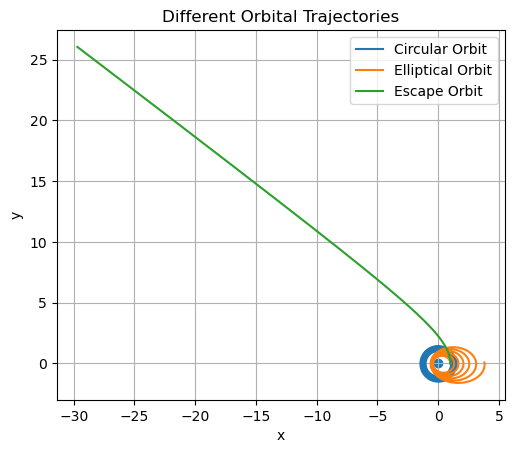

In [3]:
x0, y0 = 1, 0

conditions = {
    "Circular Orbit": (0, 2*np.pi),
    "Elliptical Orbit": (0, 1.5*np.pi),
    "Escape Orbit": (0, 3*np.pi)
}

plt.figure()

for label, (vx0, vy0) in conditions.items():
    xs, ys, _ = simulate_euler(0.001, 10000, x0, y0, vx0, vy0)
    plt.plot(xs, ys, label=label)

plt.scatter(0, 0)  # central mass
plt.gca().set_aspect('equal')

plt.title("Different Orbital Trajectories")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

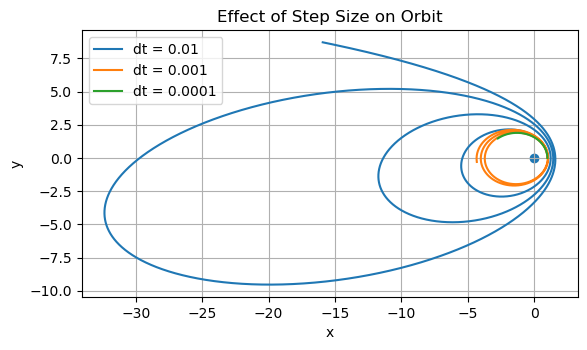

In [7]:
dt_values = [0.01, 0.001, 0.0001]

plt.figure()

for dt in dt_values:
    xs, ys, _ = simulate_euler(dt, 10000, x0, y0, 0, 2.5*np.pi)
    plt.plot(xs, ys, label=f"dt = {dt}")

plt.scatter(0, 0)
plt.gca().set_aspect('equal')

plt.title("Effect of Step Size on Orbit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

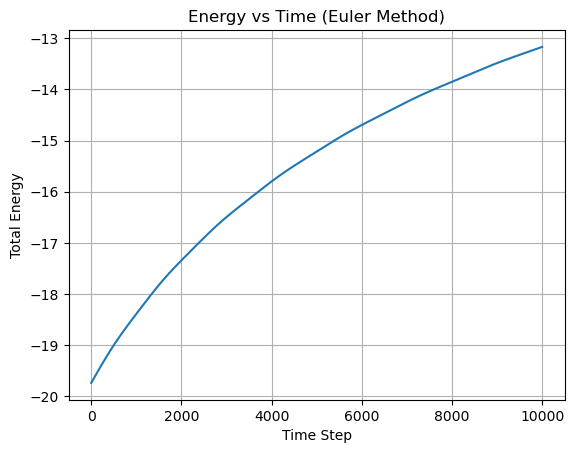

In [10]:
xs, ys, energies = simulate_euler(0.001, 10000, x0, y0, 0, 2*np.pi)

plt.figure()
plt.plot(energies)

plt.title("Energy vs Time (Euler Method)")
plt.xlabel("Time Step")
plt.ylabel("Total Energy")
plt.grid()
plt.show()

# Explanation of the Code

## Simulation Function

The function `simulate_euler` performs numerical integration using Euler's method.

### Inputs:
- `dt`: time step size
- `steps`: number of iterations
- `x0, y0`: initial position
- `vx0, vy0`: initial velocity

---

## Algorithm Steps

At each time step:

### 1. Compute Distance
$$
r = \sqrt{x^2 + y^2}
$$

---

### 2. Compute Acceleration
$$
a_x = -\frac{4\pi^2 x}{r^3}, \quad
a_y = -\frac{4\pi^2 y}{r^3}
$$

---

### 3. Update Position
$$
x \leftarrow x + v_x \Delta t
$$

$$
y \leftarrow y + v_y \Delta t
$$

---

### 4. Update Velocity
$$
v_x \leftarrow v_x + a_x \Delta t
$$

$$
v_y \leftarrow v_y + a_y \Delta t
$$

---

### 5. Store Results
- Position values are stored for plotting trajectory
- Energy is computed and stored

---

## Orbit Types

Different trajectories are obtained by changing initial velocity:

- Circular orbit: $v = 2\pi$
- Elliptical orbit: $v < 2\pi$
- Escape orbit: $v > 2\pi$

---

## Step Size Effect

- Large $\Delta t$: inaccurate and unstable results
- Small $\Delta t$: more accurate simulation

---

## Energy Behavior

- Euler method does not conserve energy
- Energy shows drift over time

# Observations

1. The shape of the orbit depends on the initial velocity.
2. Circular orbit occurs when gravitational force balances centripetal force.
3. Lower velocities produce elliptical orbits.
4. Higher velocities result in escape trajectories.

---

# Effect of Step Size

- Larger step sizes cause distortion in the orbit.
- Smaller step sizes improve accuracy but increase computation time.

---

# Energy Analysis

- Total energy is not conserved using Euler's method.
- Energy shows a gradual drift over time.

---

# Conclusion

- Euler's method is simple but introduces numerical errors.
- The method is not suitable for long-term simulations of conservative systems.
- More advanced methods like Verlet integration are preferred for better accuracy.